In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())


   customer_id  gender  age  annual_income  spending_score
0            1    Male   19             15              39
1            2    Male   21             15              81
2            3  Female   20             16               6
3            4  Female   23             16              77
4            5  Female   31             17              40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    int64 
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
X = df[['annual_income',
        'spending_score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

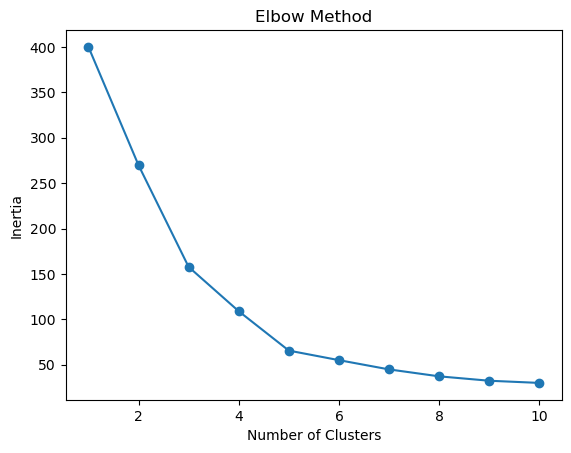

In [12]:
from sklearn.cluster import KMeans
inertias = []
for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


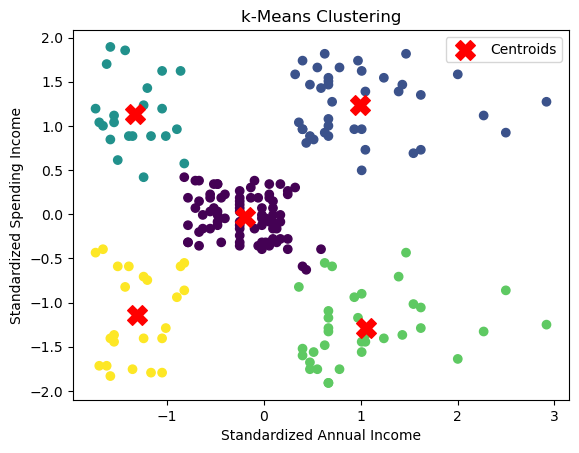

In [16]:
k=5
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap='viridis'
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Income")
plt.title("k-Means Clustering")
plt.legend()
plt.show()

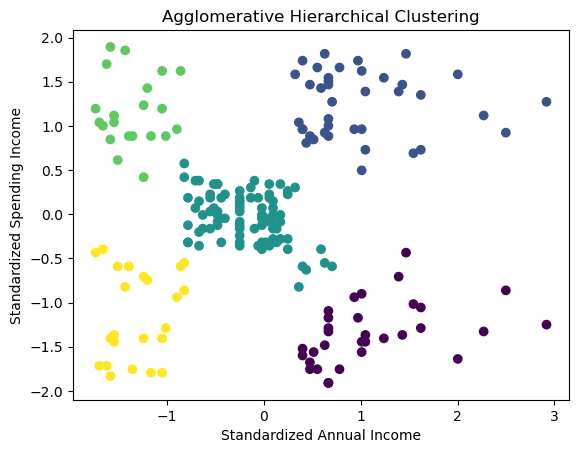

In [17]:
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)
hierarchical_labels = (
    hierarchical.fit_predict(X_scaled)
)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=hierarchical_labels,
    cmap='viridis'
)
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Income")
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

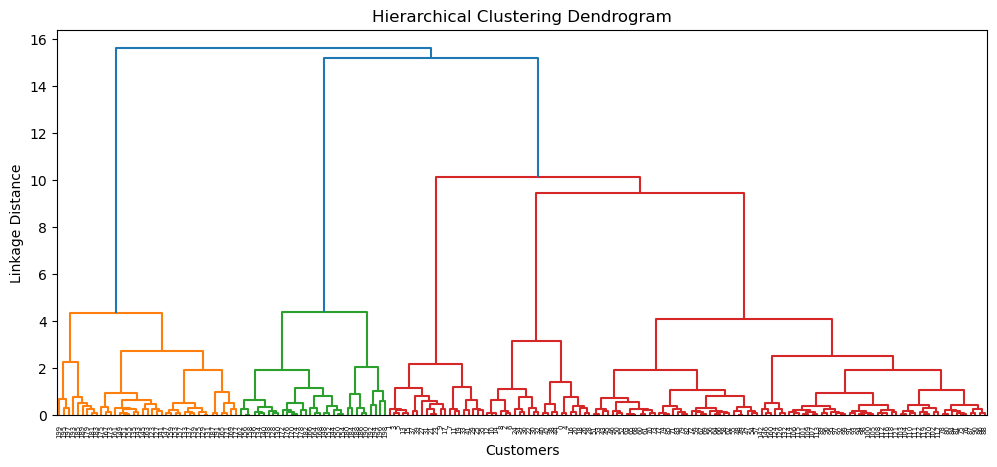

In [20]:
from scipy.cluster.hierarchy import (
   linkage, dendrogram
)
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Linkage Distance")
plt.show()